# Dataset Overview

This notebook summarizes the variant-labeling datasets produced by the NGS pipeline across first-round and second-round roots.
It reads summary CSVs where available and raw `*.variant_labeling.csv` files for roots that do not have a summary file yet.

Labels are counted from the summary columns: **specific** = `n_spec_1`, **unspecific** = `n_spec_0`, and **uncertain** = `n_spec_2`.

A3 Q20 and Q30 are available for comparison below; DMF5 is autodetected and plotted when present.

,dataset,quality,mode_folder,mode_label,peptides,total_labels,uncertain_labels,unspecific_labels,specific_labels,uncertain_share,unspecific_share,specific_share,summary_path
0,A3,first,07_01_2026_minlength191_Q20,combined,10,1653227,1198137,400474,54616,0.724726,0.242238,0.033036,raw variant_labeling files
1,A3,second,single_positive_3x,3x enriched,10,1444060,1031673,381347,31040,0.714425,0.264080,0.021495,/cluster/project/reddy/katja/NGS_pipeline/data...
2,A3,second,single_positive_3x1x,3x1x enriched,10,1444060,1041727,382425,19908,0.721388,0.264826,0.013786,/cluster/project/reddy/katja/NGS_pipeline/data...
3,A3,second,combined,combined,10,1444060,1023481,379435,41144,0.708752,0.262756,0.028492,/cluster/project/reddy/katja/NGS_pipeline/data...
4,A3,second,monotonic,monotonic,10,1444060,1055511,384621,3928,0.730933,0.266347,0.002720,/cluster/project/reddy/katja/NGS_pipeline/data...


,dataset,quality,status,expected_modes
0,A3,first-quality,not yet produced,"3x enriched, 3x1x enriched, combined, monotonic"
1,DMF5,first-quality,not yet produced,"1x enriched, 2x1x enriched, combined, monotonic"


Found 7429467 label rows across 5 available dataset/mode combinations.
Pending first-quality dataset groups: 2


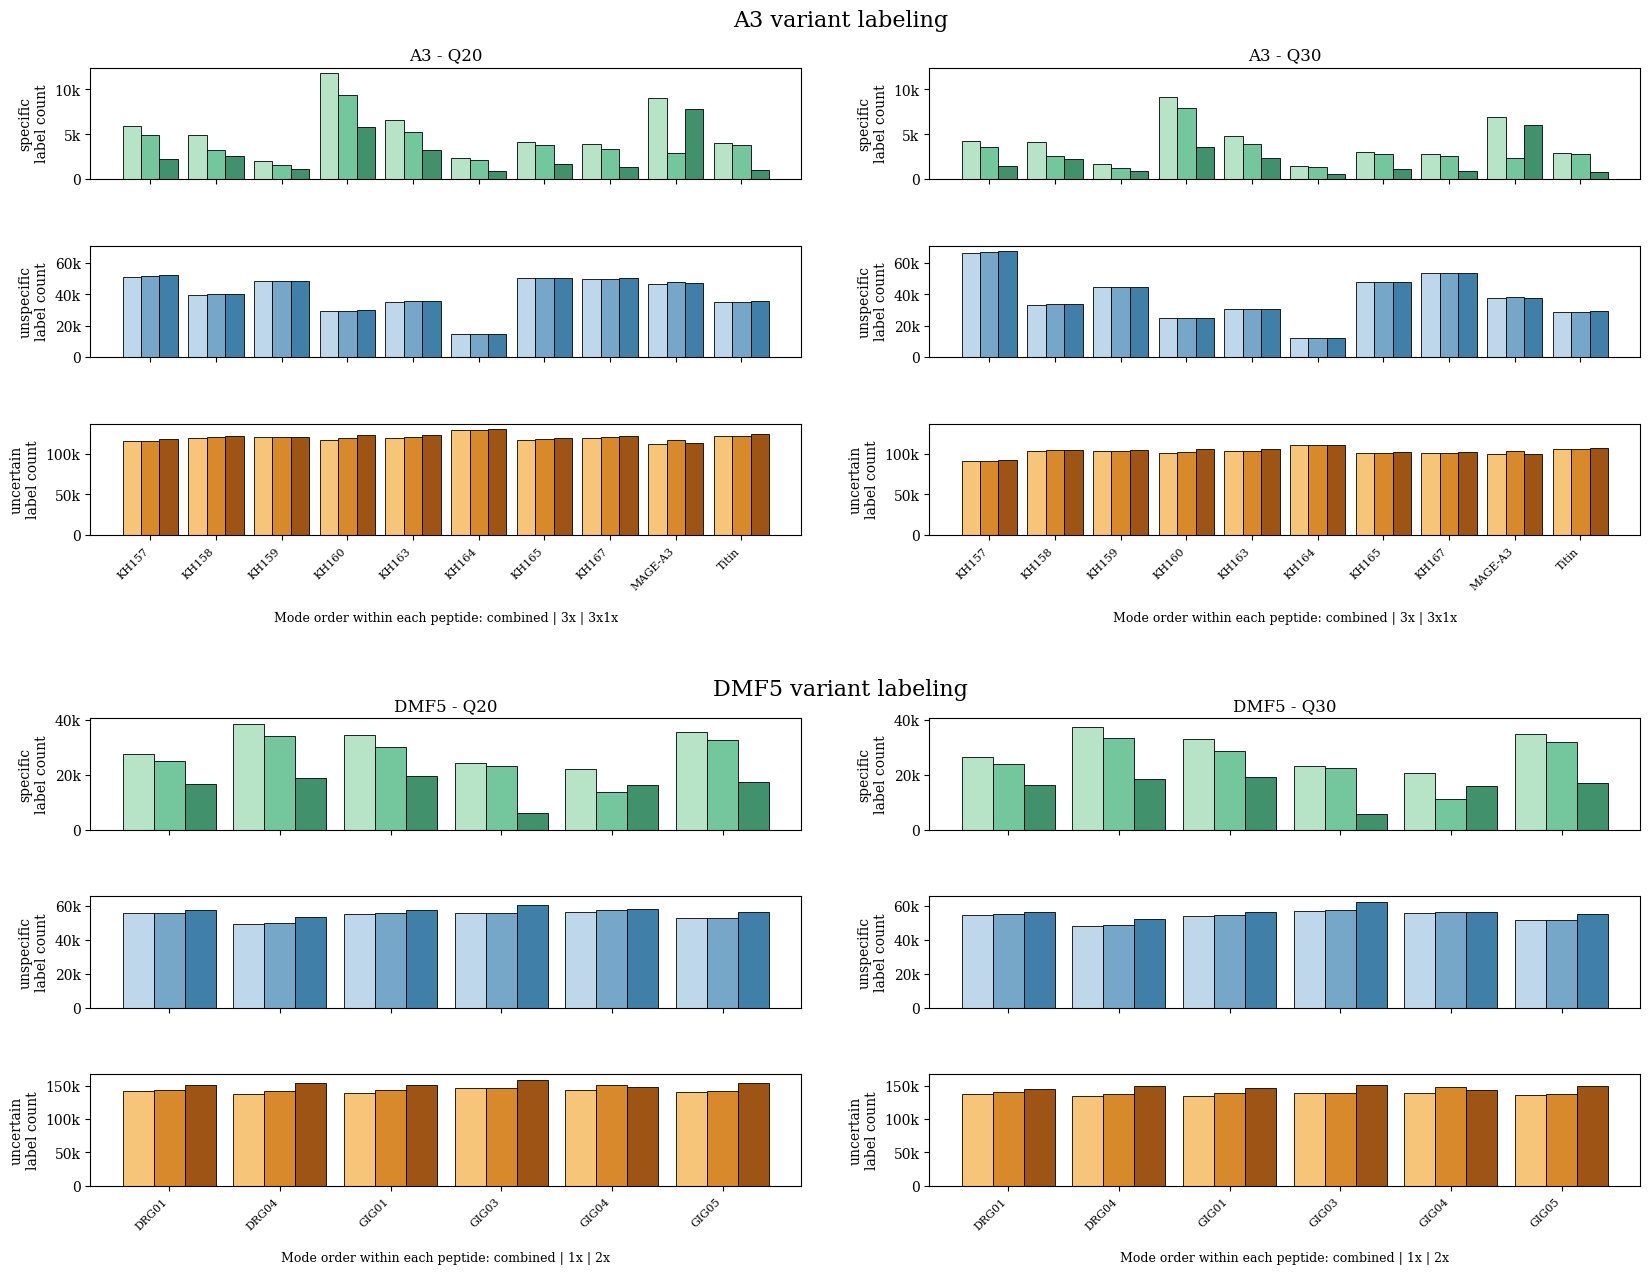

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter
from IPython.display import display

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "Nimbus Roman", "Liberation Serif", "DejaVu Serif"],
})

def format_k_ticks(value, _):
    if abs(value) >= 1000:
        return f"{value / 1000:g}k"
    return f"{value:g}"


base = Path("/cluster/project/reddy/katja/NGS_pipeline/data")

summary_filenames = ["variant_labeling_summary.csv", "script4_variant_labeling_summary.csv"]


def summarize_summary_file(summary_path, dataset, quality, mode_label, mode_folder):
    summary_df = pd.read_csv(summary_path)
    n_variants = pd.to_numeric(summary_df.get("n_variants"), errors="coerce").fillna(0)
    n_spec_0 = pd.to_numeric(summary_df.get("n_spec_0"), errors="coerce").fillna(0)
    n_spec_1 = pd.to_numeric(summary_df.get("n_spec_1"), errors="coerce").fillna(0)
    n_spec_2 = pd.to_numeric(summary_df.get("n_spec_2"), errors="coerce").fillna(0)

    total_labels = int(n_variants.sum())
    specific_labels = int(n_spec_1.sum())
    unspecific_labels = int(n_spec_0.sum())
    uncertain_labels = int(n_spec_2.sum())
    peptides = int(summary_df["peptide"].nunique()) if "peptide" in summary_df.columns else total_labels

    return {
        "dataset": dataset,
        "quality": quality,
        "mode_folder": mode_folder,
        "mode_label": mode_label,
        "peptides": peptides,
        "total_labels": total_labels,
        "uncertain_labels": uncertain_labels,
        "unspecific_labels": unspecific_labels,
        "specific_labels": specific_labels,
        "uncertain_share": uncertain_labels / total_labels if total_labels else 0,
        "unspecific_share": unspecific_labels / total_labels if total_labels else 0,
        "specific_share": specific_labels / total_labels if total_labels else 0,
        "summary_path": str(summary_path),
    }


def summarize_raw_root(root, dataset, quality, mode_label):
    raw_files = sorted(root.glob("*.variant_labeling.csv"))
    total_labels = 0
    specific_labels = 0
    unspecific_labels = 0
    uncertain_labels = 0
    peptides = set()

    for raw_path in raw_files:
        raw_df = pd.read_csv(raw_path)
        total_labels += len(raw_df)
        specificity = pd.to_numeric(raw_df.get("specificity"), errors="coerce").fillna(-1)
        specific_labels += int((specificity == 1).sum())
        unspecific_labels += int((specificity == 0).sum())
        uncertain_labels += int((specificity == 2).sum())
        if "peptide" in raw_df.columns:
            peptides.update(raw_df["peptide"].dropna().astype(str).unique())

    return {
        "dataset": dataset,
        "quality": quality,
        "mode_folder": root.name,
        "mode_label": mode_label,
        "peptides": len(peptides) if peptides else len(raw_files),
        "total_labels": total_labels,
        "uncertain_labels": uncertain_labels,
        "unspecific_labels": unspecific_labels,
        "specific_labels": specific_labels,
        "uncertain_share": uncertain_labels / total_labels if total_labels else 0,
        "unspecific_share": unspecific_labels / total_labels if total_labels else 0,
        "specific_share": specific_labels / total_labels if total_labels else 0,
        "summary_path": "raw variant_labeling files",
    }


def collect_from_summary_dirs(root, dataset, quality, mode_labels):
    rows = []
    if not root.exists():
        return rows

    for mode_dir in sorted(path for path in root.iterdir() if path.is_dir()):
        for summary_name in summary_filenames:
            summary_path = mode_dir / summary_name
            if summary_path.exists():
                rows.append(
                    summarize_summary_file(
                        summary_path,
                        dataset=dataset,
                        quality=quality,
                        mode_label=mode_labels.get(mode_dir.name, mode_dir.name),
                        mode_folder=mode_dir.name,
                    )
                )
                break

    return rows


dataset_specs = [
    {
        "dataset": "A3",
        "quality": "second",
        "root": base / "P3408_LUCA-TCRA3/04_variant_labeling/19_05_2026_minlenght191_Q30",
        "source": "summary_dirs",
        "mode_labels": {
            "combined": "combined",
            "monotonic": "monotonic",
            "single_positive_3x": "3x enriched",
            "single_positive_3x1x": "3x1x enriched",
        },
    },
    {
        "dataset": "A3",
        "quality": "first",
        "root": base / "P3408_LUCA-TCRA3/04_variant_labeling/07_01_2026_minlength191_Q20",
        "source": "raw_root",
        "mode_label": "combined",
    },
    {
        "dataset": "DMF5",
        "quality": "second",
        "root": base / "P3481_LUCA-TCRDMF5/04_variant_labeling",
        "source": "summary_dirs",
        "mode_labels": {
            "combined": "combined",
            "monotonic": "monotonic",
            "single_positive_pos1x": "1x enriched",
            "single_positive_pos2x": "2x enriched",
        },
    },
    ]

pending_rows = [
    {"dataset": "A3", "quality": "first-quality", "status": "not yet produced", "expected_modes": "3x enriched, 3x1x enriched, combined, monotonic"},
    {"dataset": "DMF5", "quality": "first-quality", "status": "not yet produced", "expected_modes": "1x enriched, 2x1x enriched, combined, monotonic"},
]

overview_rows = []
source_rows = 0

for spec in dataset_specs:
    root = spec["root"]
    if not root.exists():
        continue

    if spec["source"] == "summary_dirs":
        rows = collect_from_summary_dirs(root, spec["dataset"], spec["quality"], spec.get("mode_labels", {}))
        overview_rows.extend(rows)
        source_rows += sum(row["total_labels"] for row in rows)
        continue

    if spec["source"] == "summary_file":
        summary_path = spec["root"] / spec["summary_file"]
        if summary_path.exists():
            row = summarize_summary_file(
                summary_path,
                dataset=spec["dataset"],
                quality=spec["quality"],
                mode_label=spec.get("mode_label", spec["root"].name),
                mode_folder=spec["root"].name,
            )
            overview_rows.append(row)
            source_rows += row["total_labels"]
        continue

    if spec["source"] == "raw_root":
        row = summarize_raw_root(
            root,
            dataset=spec["dataset"],
            quality=spec["quality"],
            mode_label=spec.get("mode_label", root.name),
        )
        overview_rows.append(row)
        source_rows += row["total_labels"]
        continue

overview = pd.DataFrame(overview_rows).sort_values(["dataset", "quality", "mode_label"]).reset_index(drop=True)
overview = overview[[
    "dataset",
    "quality",
    "mode_folder",
    "mode_label",
    "peptides",
    "total_labels",
    "uncertain_labels",
    "unspecific_labels",
    "specific_labels",
    "uncertain_share",
    "unspecific_share",
    "specific_share",
    "summary_path",
]]

if overview.empty:
    raise FileNotFoundError("No variant labeling files were found under the configured dataset roots.")

display(overview)
display(pd.DataFrame(pending_rows))

print(f"Found {source_rows} label rows across {len(overview)} available dataset/mode combinations.")
print(f"Pending first-quality dataset groups: {len(pending_rows)}")

def load_mode_class_frame(root, mode_specs):
    frame = None
    for mode_spec in mode_specs:
        summary_path = root / mode_spec["folder"] / mode_spec["summary_name"]
        if not summary_path.exists():
            continue

        mode_df = pd.read_csv(summary_path)
        required_columns = ["peptide", "n_spec_1", "n_spec_0", "n_spec_2"]
        missing_columns = [column for column in required_columns if column not in mode_df.columns]
        if missing_columns:
            raise ValueError(f"{summary_path} is missing columns: {missing_columns}")

        mode_df = mode_df[required_columns].rename(columns={
            "n_spec_1": f"{mode_spec['slug']}_specific",
            "n_spec_0": f"{mode_spec['slug']}_unspecific",
            "n_spec_2": f"{mode_spec['slug']}_uncertain",
        })
        frame = mode_df if frame is None else frame.merge(mode_df, on="peptide", how="outer")

    if frame is None:
        return pd.DataFrame()

    return frame.fillna(0).sort_values("peptide").reset_index(drop=True)


def plot_grouped_mode_class_rows(axes, frame, title, mode_specs):
    class_specs = [
        ("specific", "specific", ["#B7E4C7", "#74C69D", "#40916C", "#2D6A4F", "#1B4332"]),
        ("unspecific", "unspecific", ["#BFD7EA", "#76A7C8", "#3F7FA8", "#1F5A7A", "#12384F"]),
        ("uncertain", "uncertain", ["#F6C57A", "#D8892B", "#9E5414", "#6E3510", "#3D1D0A"]),
    ]

    if frame.empty:
        for ax in axes:
            ax.axis("off")
            ax.text(0.5, 0.5, "Data pending", ha="center", va="center", fontsize=14, transform=ax.transAxes)
        axes[0].set_title(title)
        return {class_name: 0 for class_name, _, _ in class_specs}

    peptides = frame["peptide"].tolist()
    positions = np.arange(len(peptides))
    group_width = 0.84
    bar_width = group_width / len(mode_specs)
    offsets = (np.arange(len(mode_specs)) - (len(mode_specs) - 1) / 2) * bar_width
    max_heights = {}
    for ax, (class_name, label, shade_colors) in zip(axes, class_specs):
        max_height = 0
        for mode_index, (offset, mode_spec) in enumerate(zip(offsets, mode_specs)):
            column_name = f"{mode_spec['slug']}_{class_name}"
            values = frame[column_name].to_numpy() if column_name in frame.columns else np.zeros(len(peptides))
            ax.bar(positions + offset, values, bar_width, color=shade_colors[mode_index % len(shade_colors)], edgecolor="black", linewidth=0.6, label=mode_spec["label"])
            max_height = max(max_height, float(values.max()) if len(values) else 0)

        ax.set_ylabel(f"{label}\nlabel count")
        ax.set_ylim(0, max_height * 1.05 if max_height else 1)
        ax.yaxis.set_major_formatter(FuncFormatter(format_k_ticks))
        ax.set_xticks(positions)
        if ax is not axes[-1]:
            ax.set_xticklabels([])
        ax.tick_params(axis="x", which="major", pad=4, labelsize=8)
        max_heights[class_name] = max_height

    axes[0].set_title(title)
    axes[-1].set_xticks(positions)
    axes[-1].set_xticklabels(peptides, rotation=45, ha="right")
    mode_order = " | ".join(mode_spec["label"] for mode_spec in mode_specs)
    axes[-1].set_xlabel(f"Mode order within each peptide: {mode_order}", fontsize=9, labelpad=14)
    return max_heights


a3_q20_root = base / "P3408_LUCA-TCRA3/04_variant_labeling/07_01_2026_minlenght191_Q20_new"
a3_q30_root = base / "P3408_LUCA-TCRA3/04_variant_labeling/19_05_2026_minlenght191_Q30"
a3_mode_specs_q20 = [
    {"label": "combined", "slug": "combined", "folder": "combined", "summary_name": "variant_labeling_summary.csv"},
    {"label": "3x", "slug": "three_x", "folder": "single_positives_3x", "summary_name": "variant_labeling_summary.csv"},
    {"label": "3x1x", "slug": "three_x_one_x", "folder": "single_positives_3x1x", "summary_name": "variant_labeling_summary.csv"},
]
a3_mode_specs_q30 = [
    {"label": "combined", "slug": "combined", "folder": "combined", "summary_name": "variant_labeling_summary.csv"},
    {"label": "3x", "slug": "three_x", "folder": "single_positive_3x", "summary_name": "variant_labeling_summary.csv"},
    {"label": "3x1x", "slug": "three_x_one_x", "folder": "single_positive_3x1x", "summary_name": "variant_labeling_summary.csv"},
]

a3_q20_frame = load_mode_class_frame(a3_q20_root, a3_mode_specs_q20)
a3_q30_frame = load_mode_class_frame(a3_q30_root, a3_mode_specs_q30)


# DMF5: detect available quality roots (Q20/Q30 or similar) and plot both subplots if present
dmf5_root = base / "P3481_LUCA-TCRDMF5/04_variant_labeling"
dmf5_mode_specs = [
    {"label": "combined", "slug": "combined", "folder": "combined", "summary_name": "variant_labeling_summary.csv"},
    {"label": "1x", "slug": "one_x", "folder": "single_positive_pos1x", "summary_name": "variant_labeling_summary.csv"},
    {"label": "2x", "slug": "two_x", "folder": "single_positive_pos2x", "summary_name": "variant_labeling_summary.csv"},
]

dmf5_quality_roots = []
if dmf5_root.exists():
    for p in sorted(p for p in dmf5_root.iterdir() if p.is_dir()):
        if (p / "combined").exists():
            dmf5_quality_roots.append(p)

if not dmf5_quality_roots:
    dmf5_quality_roots = [dmf5_root]

if len(dmf5_quality_roots) >= 2:
    dmf5_q20_root, dmf5_q30_root = dmf5_quality_roots[:2]
else:
    dmf5_q20_root = dmf5_quality_roots[0]
    dmf5_q30_root = dmf5_quality_roots[0]

dmf5_q20_frame = load_mode_class_frame(dmf5_q20_root, dmf5_mode_specs)
dmf5_q30_frame = load_mode_class_frame(dmf5_q30_root, dmf5_mode_specs)

figure_variant, axes_variant = plt.subplots(7, 2, figsize=(20, 13), gridspec_kw={"height_ratios": [1, 1, 1, 0.45, 1, 1, 1]})
axes_a3 = axes_variant[:3, :]
axes_spacer = axes_variant[3, :]
axes_dmf5 = axes_variant[4:, :]
for ax in axes_spacer:
    ax.axis("off")

a3_y_max_left = plot_grouped_mode_class_rows(axes_a3[:, 0], a3_q20_frame, "A3 - Q20", a3_mode_specs_q20)
a3_y_max_right = plot_grouped_mode_class_rows(axes_a3[:, 1], a3_q30_frame, "A3 - Q30", a3_mode_specs_q30)
for row_index, class_name in enumerate(["specific", "unspecific", "uncertain"]):
    shared_a3_max = max(a3_y_max_left[class_name], a3_y_max_right[class_name])
    if shared_a3_max:
        axes_a3[row_index, 0].set_ylim(0, shared_a3_max * 1.05)
        axes_a3[row_index, 1].set_ylim(0, shared_a3_max * 1.05)

dmf5_y_max_left = plot_grouped_mode_class_rows(axes_dmf5[:, 0], dmf5_q20_frame, f"DMF5 - {dmf5_q20_root.name}", dmf5_mode_specs)
dmf5_y_max_right = plot_grouped_mode_class_rows(axes_dmf5[:, 1], dmf5_q30_frame, f"DMF5 - {dmf5_q30_root.name}", dmf5_mode_specs)
for row_index, class_name in enumerate(["specific", "unspecific", "uncertain"]):
    shared_dmf5_max = max(dmf5_y_max_left[class_name], dmf5_y_max_right[class_name])
    if shared_dmf5_max:
        axes_dmf5[row_index, 0].set_ylim(0, shared_dmf5_max * 1.05)
        axes_dmf5[row_index, 1].set_ylim(0, shared_dmf5_max * 1.05)

figure_variant.text(0.5, 0.985, "A3 variant labeling", ha="center", va="top", fontsize=16)
figure_variant.text(0.5, 0.47, "DMF5 variant labeling", ha="center", va="top", fontsize=16)
figure_variant.subplots_adjust(top=0.94, bottom=0.08, hspace=0.65, wspace=0.18)
plt.show()